In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve, precision_recall_curve)
import xgboost as xgb
import matplotlib.pyplot as plt
import joblib

df = pd.read_csv("data/ml_ready.csv")

feature_cols = [c for c in df.columns
                if c not in ["distressed","company","sector"]]

X = df[feature_cols]
y = df["distressed"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set : {X_train.shape[0]} rows")
print(f"Test set     : {X_test.shape[0]} rows")
print(f"Distressed in test: {y_test.sum()} companies")


Training set : 280 rows
Test set     : 70 rows
Distressed in test: 26 companies


In [4]:
import xgboost as xgb
import joblib
import os

# create models folder if not exists
os.makedirs("models", exist_ok=True)

model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=2,
    random_state=42,
    eval_metric="auc"
)

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=50
)

joblib.dump(model, "models/xgboost_model.pkl")

print("Model saved to models/xgboost_model.pkl")

[0]	validation_0-auc:0.72727
[50]	validation_0-auc:0.72290
[100]	validation_0-auc:0.72815
[150]	validation_0-auc:0.72727
[199]	validation_0-auc:0.71591
Model saved to models/xgboost_model.pkl


CLASSIFICATION REPORT
              precision    recall  f1-score   support

     Healthy       0.74      0.70      0.72        44
  Distressed       0.54      0.58      0.56        26

    accuracy                           0.66        70
   macro avg       0.64      0.64      0.64        70
weighted avg       0.66      0.66      0.66        70



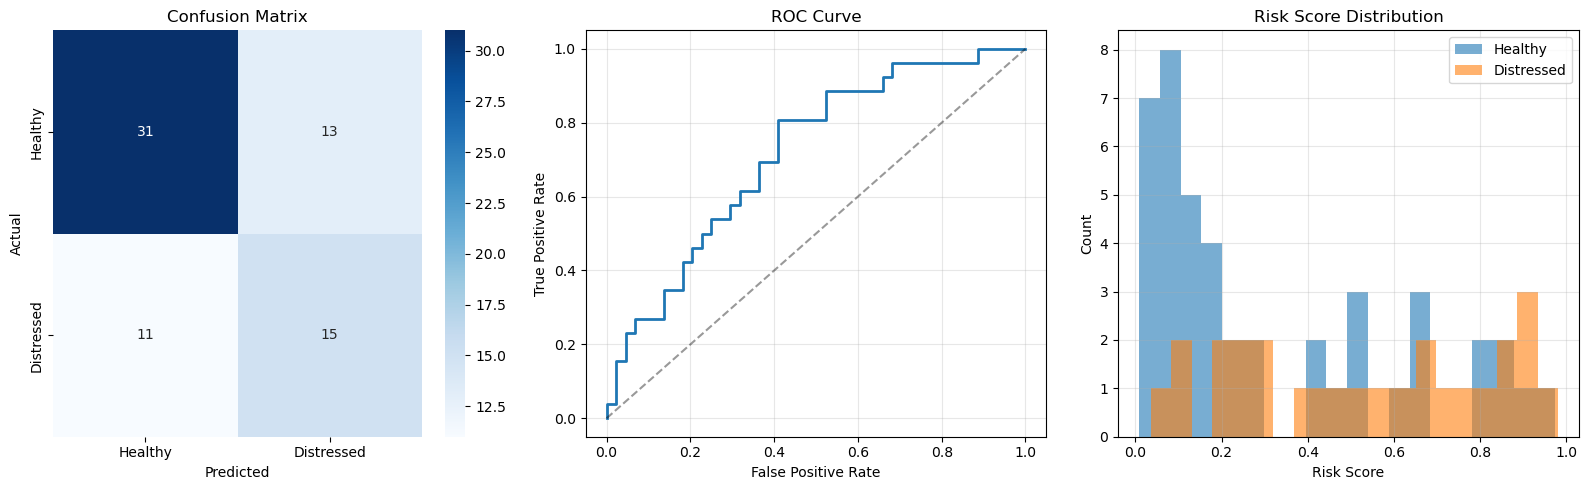

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve

# Predictions
y_pred = model.predict(X_test)
y_pred_prob = model.predict_proba(X_test)[:, 1]

print("="*50)
print("CLASSIFICATION REPORT")
print("="*50)

print(classification_report(
    y_test,
    y_pred,
    target_names=["Healthy", "Distressed"]
))

print("="*50)

# --- Plot setup ---
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    ax=axes[0],
    xticklabels=["Healthy", "Distressed"],
    yticklabels=["Healthy", "Distressed"]
)
axes[0].set_title("Confusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
axes[1].plot(fpr, tpr, lw=2)
axes[1].plot([0, 1], [0, 1], "k--", alpha=0.4)
axes[1].set_title("ROC Curve")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].grid(alpha=0.3)

# Risk Score Distribution
axes[2].hist(y_pred_prob[y_test == 0], bins=20, alpha=0.6, label="Healthy")
axes[2].hist(y_pred_prob[y_test == 1], bins=20, alpha=0.6, label="Distressed")
axes[2].set_title("Risk Score Distribution")
axes[2].set_xlabel("Risk Score")
axes[2].set_ylabel("Count")
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()